## ROOT analysis for `./20260205-1/tgf.root`

This notebook does two things:
1) Read the ROOT file.
2) Mine as much information as possible and visualize it with physical-meaning comments.

Packages used: `uproot`, `awkward`, `numpy`, `matplotlib`.
No additional dependency is required.
        


In [23]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

root_path = "./20260205-1/tgf.root"
f = uproot.open(root_path)

print(f"Opened ROOT file: {root_path}")
print(f"Number of objects: {len(f.keys())}")
print()
print("Objects (key / class / title):")
for key in f.keys():
    obj = f[key]
    print(f"- {key:24s} {obj.classname:10s}  {obj.title}")
        


Opened ROOT file: ./20260205-1/tgf.root
Number of objects: 17

Objects (key / class / title):
- event;1                  TTree       Per-event summary
- incE;1                   TH1D        Incident gamma kinetic energy at scoring plane;E (MeV);counts
- edep;1                   TH1D        Total energy deposited in NaI per event;Edep (MeV);events
- ereco;1                  TH1D        Reconstructed energy (smeared) per event;E (MeV);events
- nInc;1                   TH1D        Incident gamma multiplicity per event;N;events
- trig;1                   TH1D        Trigger flag (0/1);flag;events
- nPrim;1                  TH1D        Number of primary photons per event;N;events
- nEnterNaI;1              TH1D        Number of unique tracks entering NaI per event;N;events
- nEnterNaIG;1             TH1D        Number of unique gamma tracks entering NaI per event;N;events
- detE_proc_annihil;1      TH1D        NaI entry kinetic energy by creatorProcess=annihil;E (MeV);counts
- detE_proc_com

In [24]:
# Helper: ROOT title often follows: "main title;x label;y label"
def parse_title(title: str):
    parts = [p.strip() for p in str(title).split(";")]
    main = parts[0] if len(parts) > 0 else ""
    xlabel = parts[1] if len(parts) > 1 else ""
    ylabel = parts[2] if len(parts) > 2 else ""
    return main, xlabel, ylabel


# Helper: read TH1/TH2 into numpy arrays.
# TH1 returns (values, xedges), TH2 returns (values, xedges, yedges).
def hist_to_numpy(h, flow=False):
    out = h.to_numpy(flow=flow)
    if len(out) == 2:
        values, xedges = out
        return values, xedges, None
    if len(out) == 3:
        values, xedges, yedges = out
        return values, xedges, yedges
    raise ValueError(f"Unsupported histogram dimension: {len(out)}")


# Physical meaning map (inferred from Geant4 naming + ROOT titles).
key_meanings = {
    "event": "Event-level summary tree",
    "incE": "Incident gamma kinetic energy spectrum at scoring plane",
    "edep": "Total deposited energy in NaI per event",
    "ereco": "Reconstructed energy per event (after smearing)",
    "nInc": "Incident gamma multiplicity per event",
    "trig": "Trigger flag histogram (0/1)",
    "nPrim": "Primary photon multiplicity per event",
    "nEnterNaI": "Unique tracks entering NaI per event",
    "nEnterNaIG": "Unique gamma tracks entering NaI per event",
    "detE_proc_annihil": "NaI-entry kinetic energy for creatorProcess=annihil",
    "detE_proc_compt": "NaI-entry kinetic energy for creatorProcess=compt",
    "detE_proc_conv": "NaI-entry kinetic energy for creatorProcess=conv",
    "detE_proc_primary": "NaI-entry kinetic energy for creatorProcess=primary",
    "detE_proc_other": "NaI-entry kinetic energy for creatorProcess=other",
    "srcE_t": "Source gamma energy-time 2D distribution",
    "detE_t": "NaI-entry particle energy-time 2D distribution",
    "depE_t": "NaI deposited-step energy-time 2D distribution",
}

print("Object meaning quick lookup:")
for key in f.keys():
    base = key.split(";")[0]
    print(f"- {base:20s} {key_meanings.get(base, '(unlabeled)')}")
        


Object meaning quick lookup:
- event                Event-level summary tree
- incE                 Incident gamma kinetic energy spectrum at scoring plane
- edep                 Total deposited energy in NaI per event
- ereco                Reconstructed energy per event (after smearing)
- nInc                 Incident gamma multiplicity per event
- trig                 Trigger flag histogram (0/1)
- nPrim                Primary photon multiplicity per event
- nEnterNaI            Unique tracks entering NaI per event
- nEnterNaIG           Unique gamma tracks entering NaI per event
- detE_proc_annihil    NaI-entry kinetic energy for creatorProcess=annihil
- detE_proc_compt      NaI-entry kinetic energy for creatorProcess=compt
- detE_proc_conv       NaI-entry kinetic energy for creatorProcess=conv
- detE_proc_primary    NaI-entry kinetic energy for creatorProcess=primary
- detE_proc_other      NaI-entry kinetic energy for creatorProcess=other
- srcE_t               Source gamma energy

In [25]:
# Global object overview: dimensions, ranges, and in-range counts.
print("Object overview (in-range counts only, flow excluded):")
print()
for key in f.keys():
    base = key.split(";")[0]
    obj = f[key]
    main, xlabel, ylabel = parse_title(obj.title)

    if "TTree" in obj.classname:
        print(f"[{base}] {obj.classname} | entries={int(obj.num_entries)} | {main}")
        continue

    if "TH1" in obj.classname:
        values, xedges, _ = hist_to_numpy(obj, flow=False)
        print(
            f"[{base}] {obj.classname} | sum={float(values.sum()):.0f} | "
            f"x=[{xedges[0]}, {xedges[-1]}] | {main}"
        )
        continue

    if "TH2" in obj.classname:
        values, xedges, yedges = hist_to_numpy(obj, flow=False)
        print(
            f"[{base}] {obj.classname} | sum={float(values.sum()):.0f} | "
            f"x=[{xedges[0]}, {xedges[-1]}], y=[{yedges[0]}, {yedges[-1]}] | {main}"
        )
        continue

    print(f"[{base}] {obj.classname} | {main}")
        


Object overview (in-range counts only, flow excluded):

[event] TTree | entries=1 | Per-event summary
[incE] TH1D | sum=735897 | x=[0.0, 10.0] | Incident gamma kinetic energy at scoring plane
[edep] TH1D | sum=0 | x=[0.0, 10.0] | Total energy deposited in NaI per event
[ereco] TH1D | sum=0 | x=[0.0, 10.0] | Reconstructed energy (smeared) per event
[nInc] TH1D | sum=0 | x=[0.0, 200.0] | Incident gamma multiplicity per event
[trig] TH1D | sum=1 | x=[-0.5, 1.5] | Trigger flag (0/1)
[nPrim] TH1D | sum=0 | x=[0.0, 2000.0] | Number of primary photons per event
[nEnterNaI] TH1D | sum=0 | x=[0.0, 500.0] | Number of unique tracks entering NaI per event
[nEnterNaIG] TH1D | sum=0 | x=[0.0, 500.0] | Number of unique gamma tracks entering NaI per event
[detE_proc_annihil] TH1D | sum=6821 | x=[0.0, 10.0] | NaI entry kinetic energy by creatorProcess=annihil
[detE_proc_compt] TH1D | sum=708 | x=[0.0, 10.0] | NaI entry kinetic energy by creatorProcess=compt
[detE_proc_conv] TH1D | sum=596 | x=[0.0, 10.

In [26]:
# Read event-level TTree.
# Physical meaning: one scalar per event; this file currently has 1 entry.
event_tree = f["event"]
event_np = event_tree.arrays(library="np")

field_meanings = {
    "eventID": "Event index",
    "nPrimary": "Total number of primary photons",
    "nIncident": "Total incident gammas at scoring plane",
    "edepMeV": "Total deposited energy in NaI [MeV]",
    "erecoMeV": "Reconstructed event energy [MeV]",
    "triggered": "Trigger flag (0 or 1)",
    "nEnterNaI": "Unique tracks entering NaI",
    "nEnterNaIGamma": "Unique gamma tracks entering NaI",
}

print(event_tree.show())
print("Event-level scalars:")
for field, arr in event_np.items():
    print(f"- {field:15s} = {arr[0]}    # {field_meanings.get(field, '')}")

# Derived run-level ratios from this event summary.
n_primary = float(event_np["nPrimary"][0])
n_incident = float(event_np["nIncident"][0])
n_enter_nai = float(event_np["nEnterNaI"][0])
n_enter_nai_gamma = float(event_np["nEnterNaIGamma"][0])

incident_rate = n_incident / n_primary if n_primary > 0 else np.nan
enter_rate = n_enter_nai / n_primary if n_primary > 0 else np.nan
gamma_enter_rate = n_enter_nai_gamma / n_primary if n_primary > 0 else np.nan
enter_over_incident = n_enter_nai / n_incident if n_incident > 0 else np.nan

print()
print("Key derived ratios:")
print(f"- nIncident / nPrimary      = {incident_rate:.4%}")
print(f"- nEnterNaI / nPrimary      = {enter_rate:.4%}")
print(f"- nEnterNaIGamma / nPrimary = {gamma_enter_rate:.4%}")
print(f"- nEnterNaI / nIncident     = {enter_over_incident:.4%}")
        


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventID              | int32_t                  | AsDtype('>i4')
nPrimary             | int32_t                  | AsDtype('>i4')
nIncident            | int32_t                  | AsDtype('>i4')
edepMeV              | double                   | AsDtype('>f8')
erecoMeV             | double                   | AsDtype('>f8')
triggered            | int32_t                  | AsDtype('>i4')
nEnterNaI            | int32_t                  | AsDtype('>i4')
nEnterNaIGamma       | int32_t                  | AsDtype('>i4')
None
Event-level scalars:
- eventID         = 0    # Event index
- nPrimary        = 10000000    # Total number of primary photons
- nIncident       = 735897    # Total incident gammas at scoring plane
- edepMeV         = 217310.02293043927    # Total deposited energy in NaI [MeV]
- erecoMeV        = 217316.614935980

1D histogram flow statistics:
- incE                 under=0, in=735897, over=0, total=735897
- edep                 under=0, in=0, over=1, total=1
- ereco                under=0, in=0, over=1, total=1
- nInc                 under=0, in=0, over=1, total=1
- trig                 under=0, in=1, over=0, total=1
- nPrim                under=0, in=0, over=1, total=1
- nEnterNaI            under=0, in=0, over=1, total=1
- nEnterNaIG           under=0, in=0, over=1, total=1
- detE_proc_annihil    under=0, in=6821, over=0, total=6821
- detE_proc_compt      under=0, in=708, over=0, total=708
- detE_proc_conv       under=0, in=596, over=0, total=596
- detE_proc_primary    under=0, in=83629, over=0, total=83629
- detE_proc_other      under=0, in=3744, over=0, total=3744


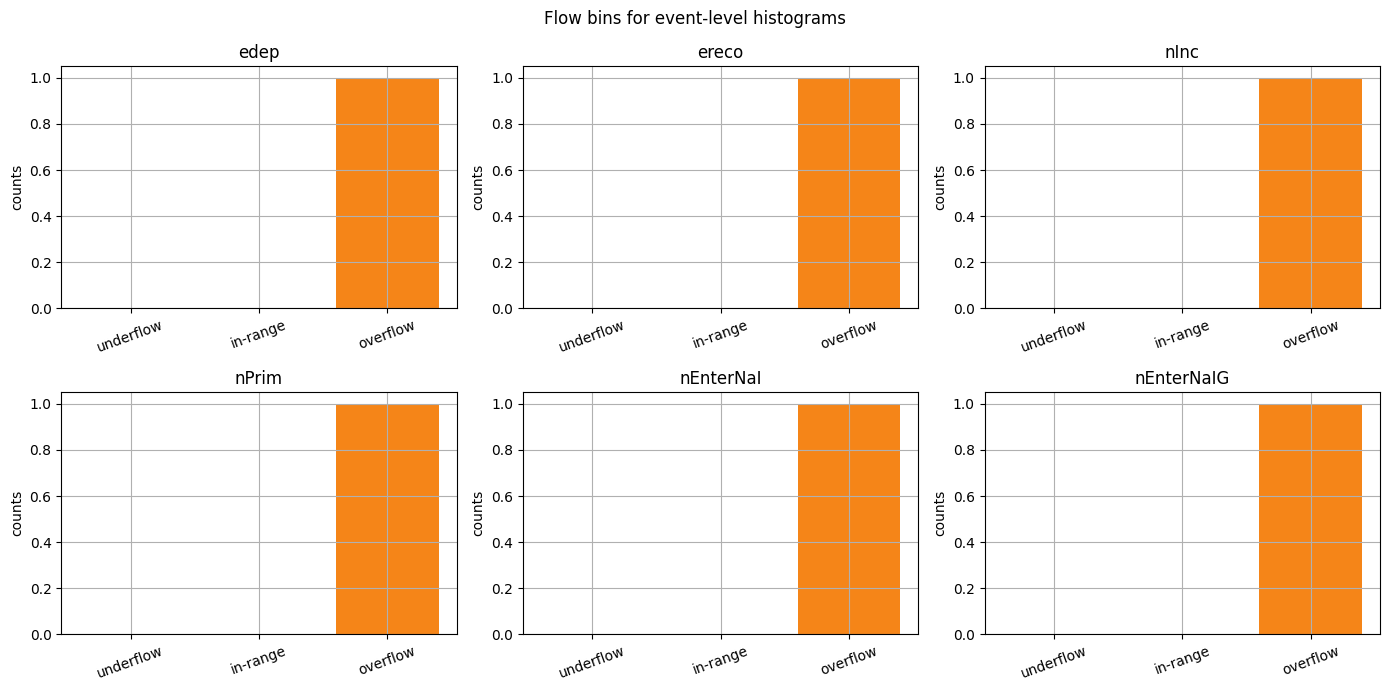

In [27]:
# Check TH1 flow bins: underflow / in-range / overflow.
# Physical meaning: large overflow means histogram range is too narrow for actual event values.
one_d_names = [
    "incE", "edep", "ereco", "nInc", "trig", "nPrim", "nEnterNaI", "nEnterNaIG",
    "detE_proc_annihil", "detE_proc_compt", "detE_proc_conv", "detE_proc_primary", "detE_proc_other",
]

print("1D histogram flow statistics:")
for name in one_d_names:
    h = f[name]
    values_flow, xedges_flow, _ = hist_to_numpy(h, flow=True)
    under = float(values_flow[0])
    in_range = float(values_flow[1:-1].sum())
    over = float(values_flow[-1])
    total = under + in_range + over
    print(f"- {name:20s} under={under:.0f}, in={in_range:.0f}, over={over:.0f}, total={total:.0f}")

# Visualize flow for event-level variables that show overflow.
overflow_focus = ["edep", "ereco", "nInc", "nPrim", "nEnterNaI", "nEnterNaIG"]
labels = ["underflow", "in-range", "overflow"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, name in zip(axes.ravel(), overflow_focus):
    h = f[name]
    values_flow, _, _ = hist_to_numpy(h, flow=True)
    bars = [float(values_flow[0]), float(values_flow[1:-1].sum()), float(values_flow[-1])]
    ax.bar(labels, bars, color=["#4C78A8", "#72B7B2", "#F58518"])
    ax.set_title(name)
    ax.set_ylabel("counts")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Flow bins for event-level histograms")
plt.tight_layout()
plt.show()
        


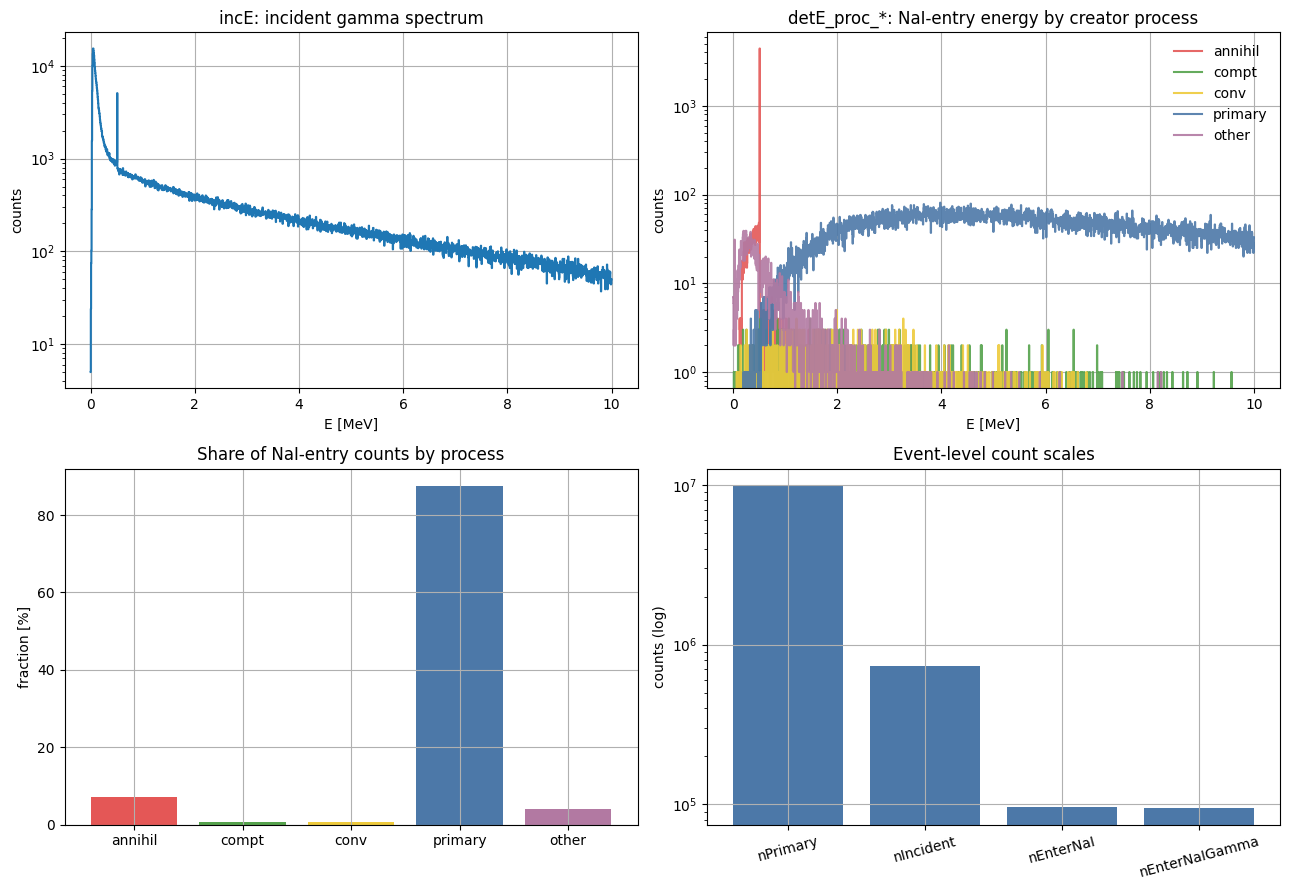

Process share details:
- annihil :       6821 (  7.14%)
- compt   :        708 (  0.74%)
- conv    :        596 (  0.62%)
- primary :      83629 ( 87.57%)
- other   :       3744 (  3.92%)


In [28]:
# 1D spectrum plots: incident energy + process-resolved NaI-entry energy.
def th1_centers_counts(h):
    values, xedges, _ = hist_to_numpy(h, flow=False)
    centers = 0.5 * (xedges[:-1] + xedges[1:])
    return centers, values, xedges

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Incident gamma spectrum at scoring plane.
inc_h = f["incE"]
inc_x, inc_y, _ = th1_centers_counts(inc_h)
axes[0, 0].step(inc_x, inc_y, where="mid", color="#1f77b4")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("E [MeV]")
axes[0, 0].set_ylabel("counts")
axes[0, 0].set_title("incE: incident gamma spectrum")

# (2) Process-resolved kinetic energy at NaI entry.
proc_names = ["annihil", "compt", "conv", "primary", "other"]
proc_colors = {
    "annihil": "#E45756",
    "compt": "#54A24B",
    "conv": "#EECA3B",
    "primary": "#4C78A8",
    "other": "#B279A2",
}
proc_totals = {}
for p in proc_names:
    h = f[f"detE_proc_{p}"]
    x, y, _ = th1_centers_counts(h)
    axes[0, 1].step(x, y, where="mid", label=p, color=proc_colors[p], alpha=0.9)
    proc_totals[p] = float(y.sum())
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("E [MeV]")
axes[0, 1].set_ylabel("counts")
axes[0, 1].set_title("detE_proc_*: NaI-entry energy by creator process")
axes[0, 1].legend(frameon=False)

# (3) Process share bar chart.
p_labels = list(proc_totals.keys())
p_values = np.array([proc_totals[k] for k in p_labels], dtype=float)
p_frac = p_values / p_values.sum() if p_values.sum() > 0 else np.zeros_like(p_values)
axes[1, 0].bar(p_labels, p_frac * 100.0, color=[proc_colors[k] for k in p_labels])
axes[1, 0].set_ylabel("fraction [%]")
axes[1, 0].set_title("Share of NaI-entry counts by process")

# (4) Event-level scale comparison (single event summary).
summary_labels = ["nPrimary", "nIncident", "nEnterNaI", "nEnterNaIGamma"]
summary_vals = [
    float(event_np["nPrimary"][0]),
    float(event_np["nIncident"][0]),
    float(event_np["nEnterNaI"][0]),
    float(event_np["nEnterNaIGamma"][0]),
]
axes[1, 1].bar(summary_labels, summary_vals, color="#4C78A8")
axes[1, 1].set_yscale("log")
axes[1, 1].set_ylabel("counts (log)")
axes[1, 1].set_title("Event-level count scales")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("Process share details:")
for k, v in proc_totals.items():
    frac = 100.0 * v / p_values.sum() if p_values.sum() > 0 else 0.0
    print(f"- {k:8s}: {v:10.0f} ({frac:6.2f}%)")
        


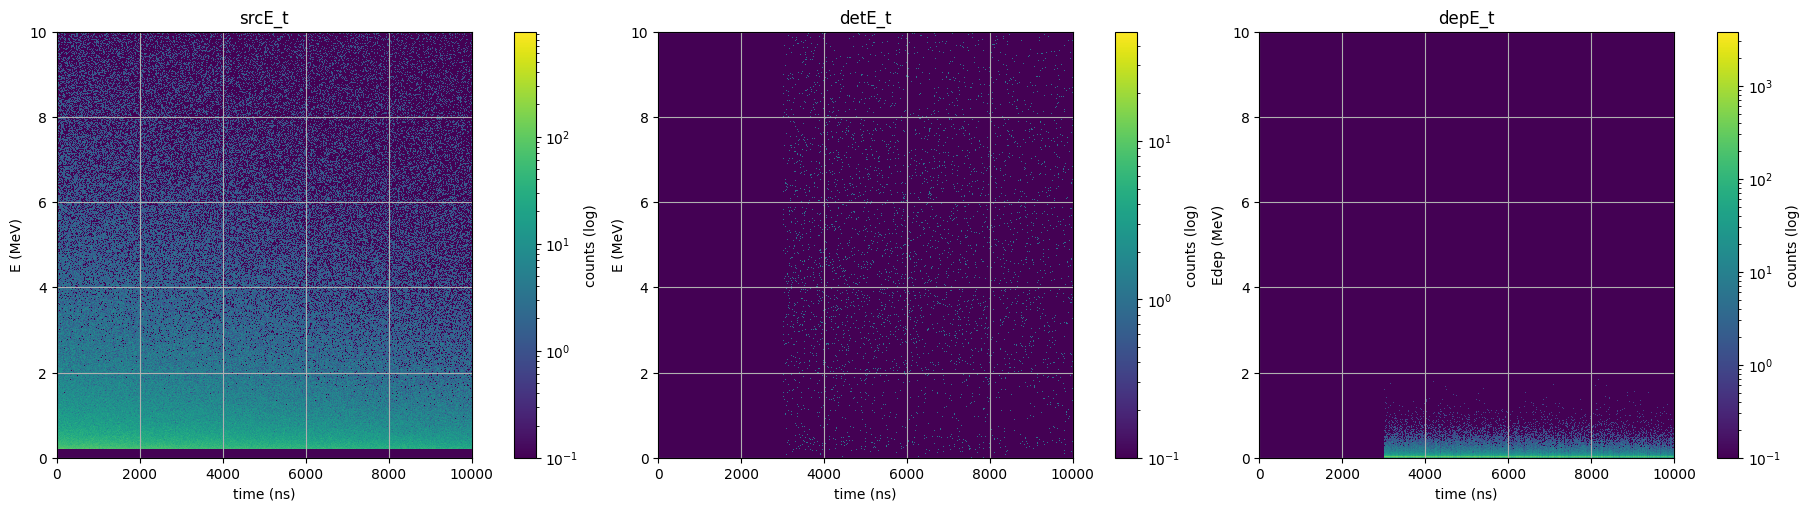

In [29]:
# 2D heatmaps: srcE_t / detE_t / depE_t.
# Physical meaning: joint structure of time [ns] and energy [MeV].
th2_names = ["srcE_t", "detE_t", "depE_t"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, name in zip(axes, th2_names):
    h = f[name]
    values, xedges, yedges = hist_to_numpy(h, flow=False)

    # Log color scale to keep both high- and low-count structures visible.
    safe_values = values.T + 1e-12
    pcm = ax.pcolormesh(
        xedges,
        yedges,
        safe_values,
        shading="auto",
        norm=LogNorm(vmin=1e-1, vmax=max(1.0, float(safe_values.max()))),
    )

    main, xlabel, ylabel = parse_title(h.title)
    ax.set_title(name)
    ax.set_xlabel(xlabel if xlabel else "time [ns]")
    ax.set_ylabel(ylabel if ylabel else "E [MeV]")

    cb = plt.colorbar(pcm, ax=ax)
    cb.set_label("counts (log)")

plt.show()
        


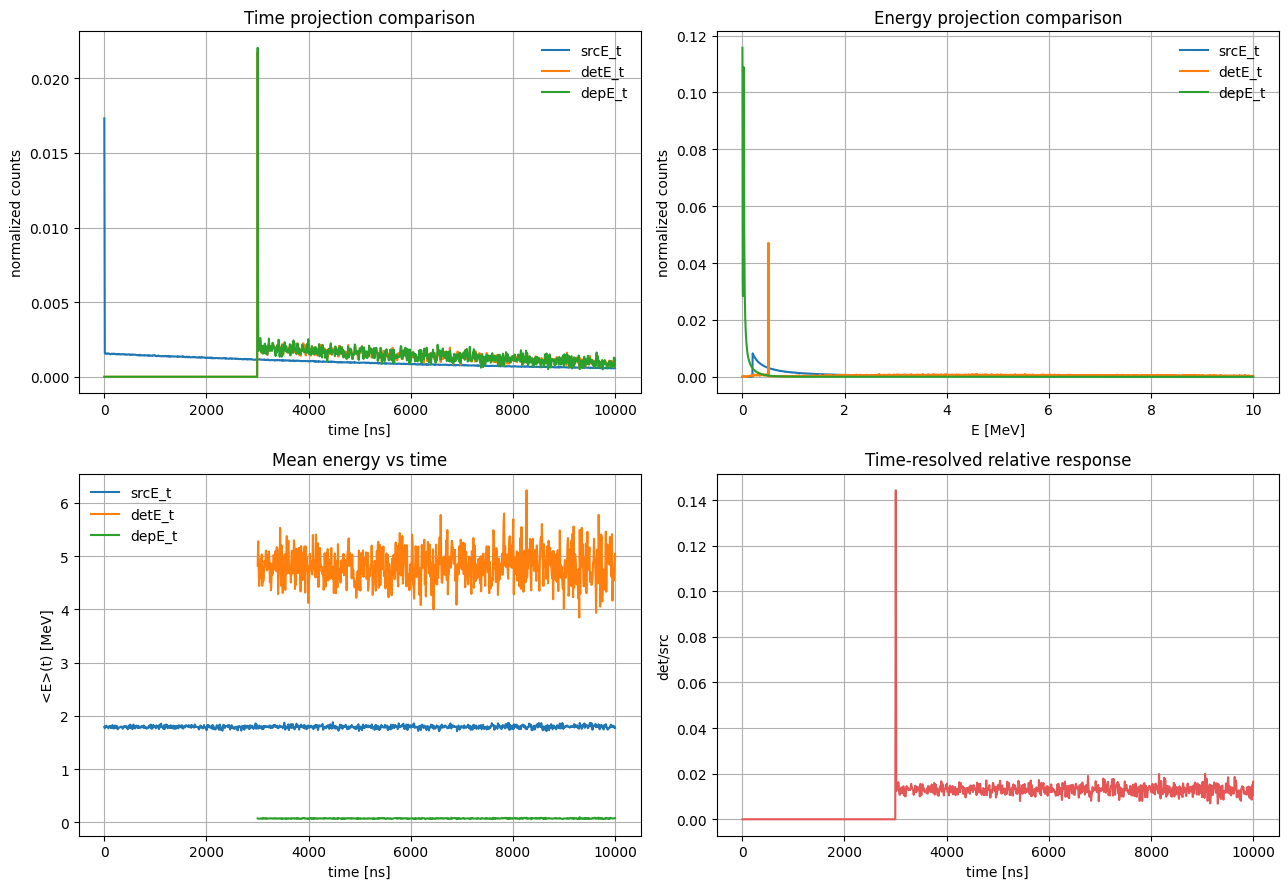

In [30]:
# Projections and derived curves from TH2:
# 1) N(t) = sum_E H(t, E)
# 2) N(E) = sum_t H(t, E)
# 3) <E>(t) = sum_E E*H(t,E) / sum_E H(t,E)
def project_th2(name):
    h = f[name]
    values, xedges, yedges = hist_to_numpy(h, flow=False)

    t_centers = 0.5 * (xedges[:-1] + xedges[1:])
    e_centers = 0.5 * (yedges[:-1] + yedges[1:])

    n_t = values.sum(axis=1)
    n_e = values.sum(axis=0)

    weighted = (values * e_centers[None, :]).sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        e_mean_t = np.divide(weighted, n_t, out=np.full_like(weighted, np.nan, dtype=float), where=n_t > 0)

    return t_centers, e_centers, n_t, n_e, e_mean_t

src_t, src_e, src_nt, src_ne, src_e_mean = project_th2("srcE_t")
det_t, det_e, det_nt, det_ne, det_e_mean = project_th2("detE_t")
dep_t, dep_e, dep_nt, dep_ne, dep_e_mean = project_th2("depE_t")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Compare normalized time projections.
def norm01(x):
    s = np.nansum(x)
    return x / s if s > 0 else x

axes[0, 0].plot(src_t, norm01(src_nt), label="srcE_t")
axes[0, 0].plot(det_t, norm01(det_nt), label="detE_t")
axes[0, 0].plot(dep_t, norm01(dep_nt), label="depE_t")
axes[0, 0].set_xlabel("time [ns]")
axes[0, 0].set_ylabel("normalized counts")
axes[0, 0].set_title("Time projection comparison")
axes[0, 0].legend(frameon=False)

# Compare normalized energy projections.
axes[0, 1].plot(src_e, norm01(src_ne), label="srcE_t")
axes[0, 1].plot(det_e, norm01(det_ne), label="detE_t")
axes[0, 1].plot(dep_e, norm01(dep_ne), label="depE_t")
axes[0, 1].set_xlabel("E [MeV]")
axes[0, 1].set_ylabel("normalized counts")
axes[0, 1].set_title("Energy projection comparison")
axes[0, 1].legend(frameon=False)

# Mean energy vs time.
axes[1, 0].plot(src_t, src_e_mean, label="srcE_t")
axes[1, 0].plot(det_t, det_e_mean, label="detE_t")
axes[1, 0].plot(dep_t, dep_e_mean, label="depE_t")
axes[1, 0].set_xlabel("time [ns]")
axes[1, 0].set_ylabel("<E>(t) [MeV]")
axes[1, 0].set_title("Mean energy vs time")
axes[1, 0].legend(frameon=False)

# Time-resolved relative response: det/src.
with np.errstate(divide="ignore", invalid="ignore"):
    det_over_src_t = np.divide(det_nt, src_nt, out=np.full_like(det_nt, np.nan, dtype=float), where=src_nt > 0)
axes[1, 1].plot(src_t, det_over_src_t, color="#E45756")
axes[1, 1].set_xlabel("time [ns]")
axes[1, 1].set_ylabel("det/src")
axes[1, 1].set_title("Time-resolved relative response")

plt.tight_layout()
plt.show()
        


In [31]:
# TH2 flow-bin check, especially for time-axis overflow.
# If xflow is large, many entries are outside the configured time window [0, 10000 ns].
for name in ["srcE_t", "detE_t", "depE_t"]:
    h = f[name]
    values_flow, xedges_flow, yedges_flow = hist_to_numpy(h, flow=True)

    core = float(values_flow[1:-1, 1:-1].sum())
    xflow = float(values_flow[0, :].sum() + values_flow[-1, :].sum())
    yflow = float(values_flow[:, 0].sum() + values_flow[:, -1].sum())
    total = float(values_flow.sum())

    print(f"{name}: core={core:.0f}, xflow={xflow:.0f}, yflow={yflow:.0f}, total={total:.0f}")
        


srcE_t: core=6357062, xflow=3642938, yflow=0, total=10000000
detE_t: core=48932, xflow=46566, yflow=0, total=95498
depE_t: core=1488541, xflow=1412762, yflow=0, total=2901303


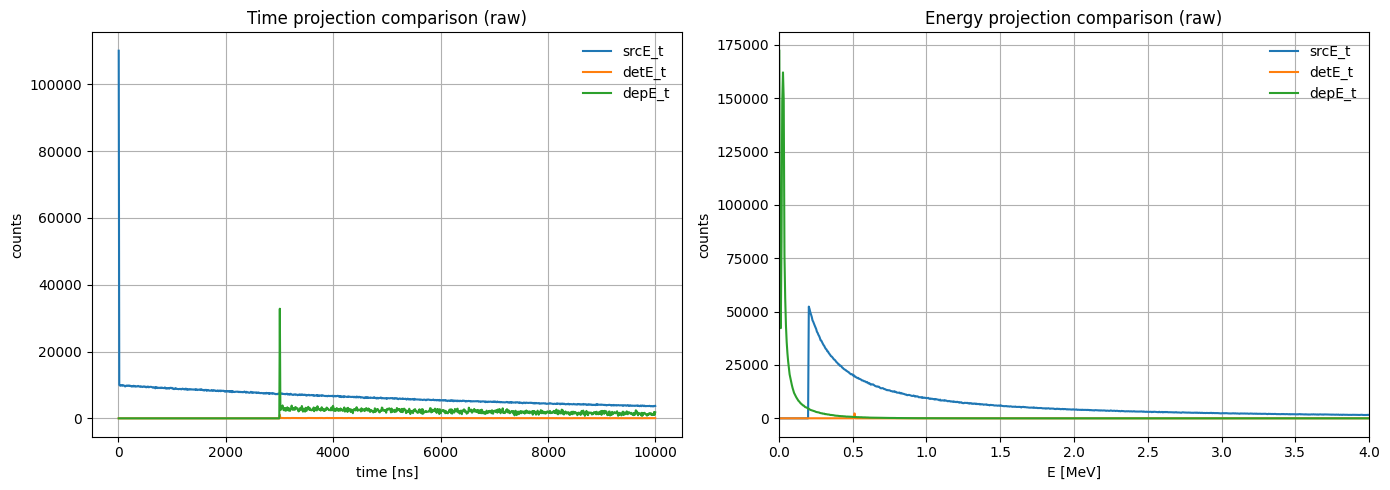

In [34]:
# Projections and derived curves from TH2 (NO normalization)
# Left: N(t) = sum_E H(t,E)
# Right: N(E) = sum_t H(t,E)
# NOTE: scales can differ by orders of magnitude; switch to log-y if needed.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time projection comparison: raw counts vs time
axes[0].plot(src_t, src_nt, label='srcE_t')
axes[0].plot(det_t, det_nt, label='detE_t')
axes[0].plot(dep_t, dep_nt, label='depE_t')
axes[0].set_xlabel('time [ns]')
axes[0].set_ylabel('counts')
axes[0].set_title('Time projection comparison (raw)')
axes[0].legend(frameon=False)

# Energy projection comparison: raw counts vs energy
axes[1].plot(src_e, src_ne, label='srcE_t')
axes[1].plot(det_e, det_ne, label='detE_t')
axes[1].plot(dep_e, dep_ne, label='depE_t')
axes[1].set_xlabel('E [MeV]')
axes[1].set_ylabel('counts')
axes[1].set_title('Energy projection comparison (raw)')
axes[1].legend(frameon=False)
axes[1].set_xlim(0, 4)

plt.tight_layout()
plt.show()
